In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
import sys

from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from scripts import (
    generate_dataset,
    optuna_search,
    predictions,
    training,
)
from experiments.plotting import _plot_SRE_distribution, view_correlation

from src.utils import configure_logger

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
logger = logging.getLogger(__name__)
configure_logger(logging.INFO, logging.INFO)

True

In [ ]:
backend = "pennylane"
target = "SRE"
method = "fwht"
use_dask = True

output_dir = "outputs/data/SRE_datasets_test"
n_bins = 50
families = "random"
n_seeds_train = 50
n_seeds_pred = 10
qubit_min, qubit_max = 4, 10
layer_min, layer_max = 80, 100
step = 2
target_qubits = "4,6,8"
max_config = None
dask_workers = 4
dask_memory = "4GiB"

: 

In [8]:
generate_dataset(
    backend=backend,
    target=target,
    method=method,
    output_dir=output_dir,
    n_bins_option=n_bins,
    families=families,
    n_seeds_option=n_seeds_train,
    prediction_n_seeds_option=n_seeds_pred,
    qubits_min=qubit_min,
    qubits_max=qubit_max,
    layers_min=layer_min,
    layers_max=layer_max,
    qubits_step=step,
    layers_step=step,
    target_qubits=target_qubits,
    max_configs=max_config,
    use_dask=use_dask,
    dask_n_workers=dask_workers,
    dask_memory_per_worker=dask_memory,
    block_size = 10,
)

2026-06-03 08:50:24,346 - GNN.dataset_builder - INFO - Processing family: random
2026-06-03 08:50:24,352 - GNN.dataset_builder - INFO - Generated 8 shards for random
2026-06-03 08:50:24,353 - parallel.dask - INFO - Creating local Dask cluster with 4 workers, 1 threads per worker.
2026-06-03 08:50:24,372 - distributed.scheduler - INFO - State start
2026-06-03 08:50:24,396 - distributed.scheduler - INFO -   Scheduler at:     tcp://127.0.0.1:58197
2026-06-03 08:50:24,398 - distributed.scheduler - INFO -   dashboard at:  http://127.0.0.1:8787/status
2026-06-03 08:50:24,398 - distributed.scheduler - INFO - Registering Worker plugin shuffle
2026-06-03 08:50:24,462 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:58202'
2026-06-03 08:50:24,463 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:58204'
2026-06-03 08:50:24,467 - distributed.nanny - INFO -         Start Nanny at: 'tcp://127.0.0.1:58200'
2026-06-03 08:50:24,469 - distributed.nanny - INFO -  

Layer block : %s (1, 80, 82, 84, 86, 88, 90, 92, 94, 96)
Layer block : %s (98, 100)


2026-06-03 08:50:25,315 - distributed.scheduler - INFO - Register worker addr: tcp://127.0.0.1:58218 name: 2
2026-06-03 08:50:25,315 - distributed.scheduler - INFO - Starting worker compute stream, tcp://127.0.0.1:58218
2026-06-03 08:50:25,316 - distributed.core - INFO - Starting established connection to tcp://127.0.0.1:58223
2026-06-03 08:50:25,316 - distributed.scheduler - INFO - Register worker addr: tcp://127.0.0.1:58217 name: 3
2026-06-03 08:50:25,318 - distributed.scheduler - INFO - Starting worker compute stream, tcp://127.0.0.1:58217
2026-06-03 08:50:25,318 - distributed.core - INFO - Starting established connection to tcp://127.0.0.1:58222
2026-06-03 08:50:25,369 - distributed.scheduler - INFO - Register worker addr: tcp://127.0.0.1:58219 name: 0
2026-06-03 08:50:25,370 - distributed.scheduler - INFO - Starting worker compute stream, tcp://127.0.0.1:58219
2026-06-03 08:50:25,370 - distributed.core - INFO - Starting established connection to tcp://127.0.0.1:58226
2026-06-03 08

In [4]:
import ast

def to_scalar(x):
    # Already numeric
    if isinstance(x, (int, float)):
        return x

    # torch / numpy scalar
    if hasattr(x, "item"):
        return x.item()

    # Strings
    if isinstance(x, str):
        x = x.strip()

        # Handle tensor(...) by stripping wrapper FIRST
        if x.startswith("tensor(") and x.endswith(")"):
            x = x[len("tensor("):-1].strip()

        try:
            val = ast.literal_eval(x)
        except Exception:
            # fallback: plain float string
            return float(x)

        # If it's a list/tuple like [10]
        if isinstance(val, (list, tuple)):
            if len(val) == 1:
                return float(val[0])
            raise ValueError(f"Unexpected list length: {val}")

        return float(val)

    raise ValueError(f"Unsupported type: {type(x)}")

In [5]:
def run(
    model_type,
    epochs,
    lr,
    loss_type,
    batch_size,
    training_mode,
    family,
    target,
    target_variant,
    model_hparams,
    train_hparams,
    training_data_dir,
    model_save_path,
    split,
    plot_qubits=10,
    plot_layers=80,
):
    training(
        epochs=epochs,
        lr=lr,
        loss_type=loss_type,
        batch_size=batch_size,
        training_mode=training_mode,
        family=family,
        target=target,
        target_variant=target_variant,
        model_type=model_type,
        model_hparams=model_hparams,
        train_hparams=train_hparams,
        training_data_dir=training_data_dir,
        split=split,
        model_save_path=model_save_path,
        show_progress=True,
        show_val_progress=False,
        log_every_n_batches=10,
        heartbeat_secs=60.0,
        epoch_time_warning_secs=600.0,
    )
    training_scope = "family" if training_mode == "per_family" else "global"
    predictions(
        model_path=model_save_path,
        model_kind=model_type,
        training_scope=training_scope,
        loss_type=loss_type,
        model_family=family,
        dataset_root=training_data_dir,
        dataset_family=family,
        batch_size=batch_size,
        global_feature_variant="binned",
        node_feature_backend_variant=None,
        plot_n_layers=plot_layers,
        plot_n_qubits=plot_qubits,
        split_by_family=True,
        show_progress=True,
    )

    df = pd.read_csv(f"../outputs/predictions/{training_scope}/{model_type}_predictions_{family}.csv")
    cols_to_fix = ["n_qubits", "n_layers", "seed"]

    for col in cols_to_fix:
        df[col] = df[col].apply(to_scalar).astype(int)
    view_correlation(
        df,
        nq=plot_qubits,
        nl=plot_layers,
        col_x="target",
        col_y="prediction",
    )
    df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
    plt.figure(figsize=(8, 6))
    plt.scatter(df["target"], df["prediction"], alpha=0.7)
    plt.plot([df["target"].min(), df["target"].max()], [df["target"].min(), df["target"].max()], "r--")  # y=x line
    plt.xlabel("True SRE")
    plt.ylabel("Predicted SRE")
    plt.title("True vs Predicted SRE for Clifford Family (GNN Model)")

In [ ]:
model_type="gnn"
epochs = 5
lr = 0.0018760928244666698
loss_type = "huber"   # "mse" | "huber"
batch_size = 32
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/datasets_SRE"
model_save_path = f"../outputs/models/{family}_model_{model_type}_{training_mode}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100
target_variant = "sre_density"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
split = "target"  # "target" | "family"


model_hparams = {
    "gnn_hidden": 32,
    "gnn_heads": 4,
    "global_hidden": 128,
    "reg_hidden": 128,
    "num_layers": 3,
    "dropout_rate": 0.13173830279748305,
}

train_hparams = {
    "weight_decay": 0.0003324725858640221,
    "grad_clip": 1.0289214665544766,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.0,
}


run(
    model_type=model_type,
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    batch_size=batch_size,
    training_mode=training_mode,
    family=family,
    target=target,
    target_variant=target_variant,
    model_hparams=model_hparams,
    train_hparams=train_hparams,
    training_data_dir=data_dir,
    split=split,
    model_save_path=model_save_path,
)

2026-06-08 11:56:24,856 - GNN.training.runners - INFO - Starting training | model_type=gnn | training_mode=per_family | family=random | loss_type=huber
2026-06-08 11:56:24,856 - GNN.training.runners - INFO - Training configuration done.
2026-06-08 11:56:24,857 - GNN.training.runners - INFO - Collecting data paths...
2026-06-08 11:56:24,858 - GNN.training.runners - INFO - Found 1 data paths.
2026-06-08 11:56:24,859 - GNN.training.runners - INFO - Data paths collected.
2026-06-08 11:56:24,859 - GNN.training.runners - INFO - Building loaders and model for model_type=gnn...
2026-06-08 11:58:21,153 - GNN.training.runners - INFO - Loaders and model built.
2026-06-08 11:58:21,154 - GNN.training.runners - INFO - Starting training...
2026-06-08 11:58:21,155 - GNN.training.train - INFO - Using device: cuda
2026-06-08 11:58:21,160 - GNN.training.train - INFO - -------- EPOCH 001 --------


Epoch 1/5:   9%|▊         | 70/804 [01:00<09:49,  1.24it/s, loss=0.0364, graphs=2272]

2026-06-08 11:59:21,615 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 71/804 | loss 0.036412 | elapsed 60.5s | graphs 2272


Epoch 1/5:  17%|█▋        | 133/804 [02:01<09:42,  1.15it/s, loss=0.0307, graphs=4288]

2026-06-08 12:00:22,507 - GNN.training.train - INFO - [Heartbeat] Epoch 1 batch 134/804 | loss 0.030679 | elapsed 121.3s | graphs 4288


...

Epoch 3/5:  51%|█████     | 411/804 [06:01<06:17,  1.04it/s, loss=0.0192, graphs=13184]

2026-06-08 12:30:22,936 - GNN.training.train - INFO - [Heartbeat] Epoch 3 batch 412/804 | loss 0.019233 | elapsed 361.8s | graphs 13184


Epoch 3/5:  60%|█████▉    | 480/804 [07:02<04:27,  1.21it/s, loss=0.0192, graphs=15392]

2026-06-08 12:31:23,190 - GNN.training.train - INFO - [Heartbeat] Epoch 3 batch 481/804 | loss 0.019200 | elapsed 422.0s | graphs 15392


Epoch 3/5:  63%|██████▎   | 506/804 [07:22<04:21,  1.14it/s, loss=0.0192, graphs=16192]

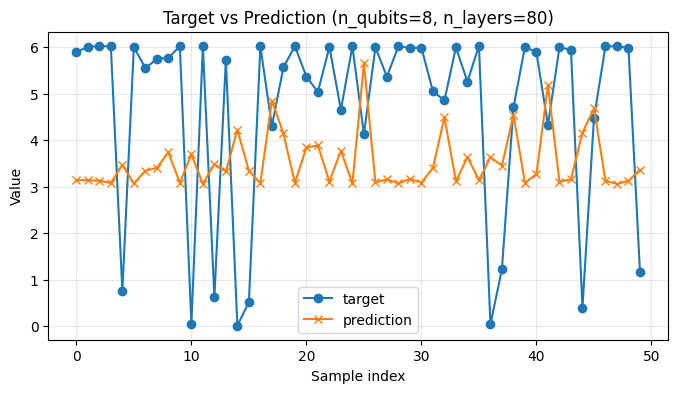

Pearson r = -0.3305


Text(0.5, 1.0, 'True vs Predicted SRE for Clifford Family (GNN Model)')

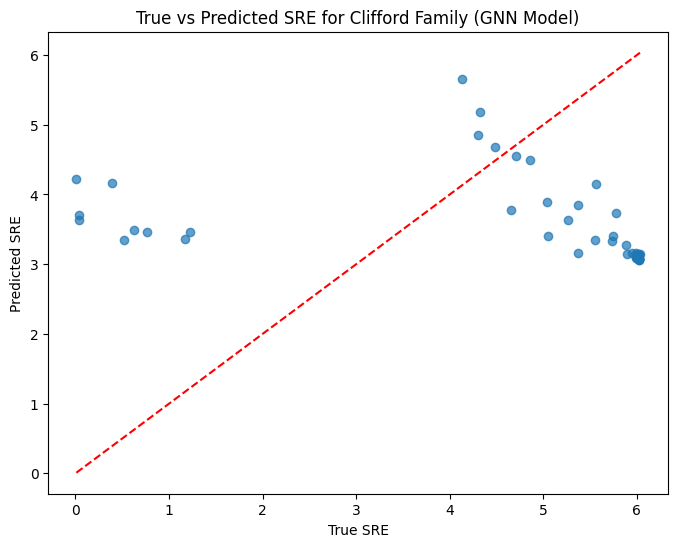

: 

In [ ]:
model_type="gnn"
epochs = 25
lr = 0.0018760928244666698
loss_type = "huber"   # "mse" | "huber"
batch_size = 16
training_mode = "per_family"  # "global" | "per_family"
family = "random"  # required if training_mode == "per_family"
target = "sre"
data_dir = "../outputs/data/SRE_datasets"
model_save_path = f"../outputs/models/{family}_model_{model_type}_{training_mode}.pt"
show_progress=True
show_val_progress=False
log_every_n_batches=10
heartbeat_secs=60.0
epoch_time_warning_secs=600.0
training_scope = "family" if training_mode == "per_family" else "global"
plot_qubits = 6
plot_layers = 100
target_variant = "sre_density"  # "sre" | "sre_density" | "log_sre" | "sqrt_sre"
split = "target"  # "target" | "family"

df = pd.read_csv(f"../outputs/predictions/{training_scope}/{model_type}_predictions_{family}.csv")
cols_to_fix = ["n_qubits", "n_layers", "seed"]
plot_qubits = 8
plot_layers = 80
for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)
view_correlation(
    df,
    nq=plot_qubits,
    nl=plot_layers,
    col_x="target",
    col_y="prediction",
)
df = df[(df["n_qubits"] == plot_qubits) & (df["n_layers"] == plot_layers)]
plt.figure(figsize=(8, 6))
plt.scatter(df["target"], df["prediction"]*plot_qubits, alpha=0.7)
plt.plot([df["target"].min(), df["target"].max()], [df["target_sre"].min(), df["target_sre"].max()], "r--")  # y=x line
plt.xlabel("True SRE")
plt.ylabel("Predicted SRE")
plt.title(f"True vs Predicted SRE for {family} Family (GNN Model)")

In [22]:
df = pd.read_csv(f"../outputs/predictions/{training_scope}/{model_type}_predictions_{family}.csv")
print(df.head())
cols_to_fix = ["n_qubits", "n_layers", "seed"]

for col in cols_to_fix:
    df[col] = df[col].apply(to_scalar).astype(int)

                           cid  family         regime       seed  n_qubits  \
0   random_q004_L001_s25064164  random  near_clifford   25064164         4   
1   random_q004_L001_s87230778  random  near_clifford   87230778         4   
2  random_q004_L001_s178507121  random  generic_dense  178507121         4   
3  random_q004_L001_s194911035  random   small_angles  194911035         4   
4  random_q004_L001_s234352163  random  near_clifford  234352163         4   

   n_layers        target  prediction_model_output    target_sre  prediction  \
0         1  1.289806e-04                 0.057255  1.289806e-04    0.057255   
1         1  9.166071e-06                 0.056616  9.166071e-06    0.056616   
2         1  5.294298e-02                 0.070406  5.294298e-02    0.070406   
3         1  1.414937e-02                 0.075939  1.414937e-02    0.075939   
4         1  1.281371e-15                 0.057392  1.281371e-15    0.057392   

      error  
0  0.057126  
1  0.056607  
2  0.017